In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from utils import load_data

X_train, X_test, y_train, y_test = load_data()

In [ ]:
# 1. One-Hot Encoding 
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
X_train_enc = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  columns=categorical_cols, drop_first=True)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join="left", axis=1, fill_value=0)

C:\Users\shrad\AppData\Local\Temp\ipykernel_14764\4051438152.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include="object").columns.tolist()


In [ ]:
# 2. The scaling experiment 
# Unlike previous models where scaling was recommended,
# for SVM it is non-negotiable. Let's prove it empirically.

# Unscaled SVM
svm_unscaled = SVC(kernel="rbf", class_weight="balanced",
                   random_state=42, probability=True)
svm_unscaled.fit(X_train_enc, y_train)
y_pred_unscaled = svm_unscaled.predict(X_test_enc)

print("── SVM WITHOUT scaling ──")
print(classification_report(y_test, y_pred_unscaled, target_names=["No", "Yes"]))

── SVM WITHOUT scaling ──
              precision    recall  f1-score   support

          No       0.91      0.43      0.58       247
         Yes       0.20      0.77      0.32        47

    accuracy                           0.48       294
   macro avg       0.55      0.60      0.45       294
weighted avg       0.79      0.48      0.54       294



In [ ]:
# Now scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled  = scaler.transform(X_test_enc)

# Scaled SVM
svm_scaled = SVC(kernel="rbf", class_weight="balanced",
                 random_state=42, probability=True)
svm_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = svm_scaled.predict(X_test_scaled)

print("\n── SVM WITH scaling ──")
print(classification_report(y_test, y_pred_scaled, target_names=["No", "Yes"]))




── SVM WITH scaling ──
              precision    recall  f1-score   support

          No       0.91      0.87      0.89       247
         Yes       0.45      0.53      0.49        47

    accuracy                           0.82       294
   macro avg       0.68      0.70      0.69       294
weighted avg       0.83      0.82      0.83       294



In [ ]:
# 3. Kernel comparison 
# Now let's see how different kernels behave on the same data
kernels = ["linear", "rbf", "poly"]
kernel_results = {}
print("\n── Kernel comparison ──")
for k in kernels:
    svm_k = SVC(kernel=k, class_weight="balanced",
                random_state=42, probability=True)
    svm_k.fit(X_train_scaled, y_train)
    y_pred_k = svm_k.predict(X_test_scaled)
    auc = roc_auc_score(y_test, svm_k.predict_proba(X_test_scaled)[:, 1])
    kernel_results[k] = {
        "model"  : svm_k,
        "y_pred" : y_pred_k,
        "auc"    : auc
    }
    print(f"\nKernel: {k.upper()} | AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred_k, target_names=["No", "Yes"]))


── Kernel comparison ──

Kernel: LINEAR | AUC: 0.7948
              precision    recall  f1-score   support

          No       0.92      0.79      0.85       247
         Yes       0.37      0.66      0.47        47

    accuracy                           0.77       294
   macro avg       0.65      0.72      0.66       294
weighted avg       0.84      0.77      0.79       294


Kernel: RBF | AUC: 0.7903
              precision    recall  f1-score   support

          No       0.91      0.87      0.89       247
         Yes       0.45      0.53      0.49        47

    accuracy                           0.82       294
   macro avg       0.68      0.70      0.69       294
weighted avg       0.83      0.82      0.83       294


Kernel: POLY | AUC: 0.6931
              precision    recall  f1-score   support

          No       0.87      0.93      0.90       247
         Yes       0.40      0.26      0.31        47

    accuracy                           0.82       294
   macro avg      

In [ ]:
# 4. C hyperparameter effect 
# C controls the tradeoff between maximizing margin width and
# minimizing misclassifications on training data.
# Small C - wider margin, more misclassifications allowed - simpler model
# Large C - narrower margin, fewer misclassifications - complex, may overfit
print("\n── Effect of C on RBF kernel ──")
C_values = [0.01, 0.1, 1, 10, 100]
c_train_scores = []
c_test_aucs    = []

for c in C_values:
    svm_c = SVC(kernel="rbf", C=c, class_weight="balanced",
                random_state=42, probability=True)
    svm_c.fit(X_train_scaled, y_train)
    train_auc = roc_auc_score(y_train, svm_c.predict_proba(X_train_scaled)[:, 1])
    test_auc  = roc_auc_score(y_test,  svm_c.predict_proba(X_test_scaled)[:, 1])
    c_train_scores.append(train_auc)
    c_test_aucs.append(test_auc)
    print(f"C={c:<6} | Train AUC: {train_auc:.4f} | Test AUC: {test_auc:.4f}")


── Effect of C on RBF kernel ──
C=0.01   | Train AUC: 0.1508 | Test AUC: 0.2163
C=0.1    | Train AUC: 0.8847 | Test AUC: 0.7991
C=1      | Train AUC: 0.9852 | Test AUC: 0.7903
C=10     | Train AUC: 1.0000 | Test AUC: 0.7372
C=100    | Train AUC: 1.0000 | Test AUC: 0.7332


In [ ]:
# 5. Support vector count 
# Fewer support vectors = simpler, more generalizable boundary
# More support vectors = complex boundary, potential overfit
print("\n── Support vectors per kernel ──")
for k, res in kernel_results.items():
    n_sv = res["model"].n_support_
    print(f"{k.upper():8} → Support vectors: {n_sv} (No={n_sv[0]}, Yes={n_sv[1]})")


── Support vectors per kernel ──
LINEAR   → Support vectors: [486 100] (No=486, Yes=100)
RBF      → Support vectors: [596 158] (No=596, Yes=158)
POLY     → Support vectors: [637 176] (No=637, Yes=176)


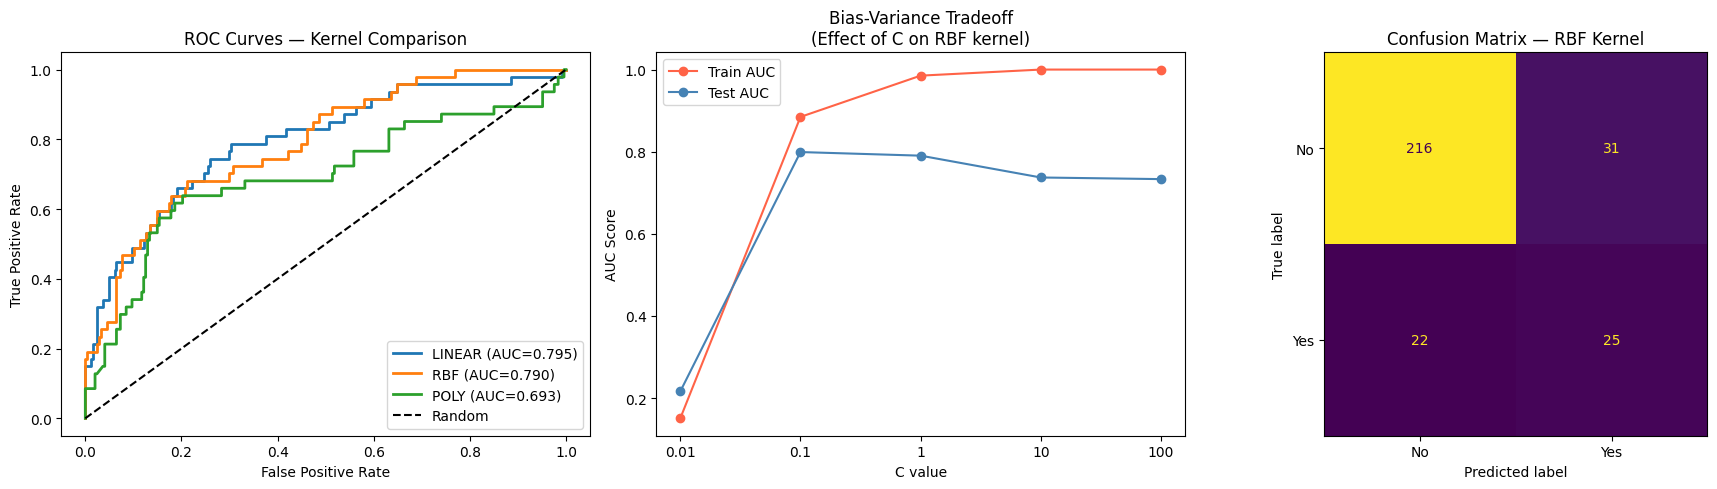

In [ ]:
# 6. Plots 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: ROC curves for all kernels
for k, res in kernel_results.items():
    proba = res["model"].predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, lw=2, label=f"{k.upper()} (AUC={res['auc']:.3f})")
axes[0].plot([0,1],[0,1], "k--", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — Kernel Comparison")
axes[0].legend()

# Plot 2: C value effect on train vs test AUC (bias-variance tradeoff)
axes[1].plot(range(len(C_values)), c_train_scores, "o-",
             color="tomato",    label="Train AUC")
axes[1].plot(range(len(C_values)), c_test_aucs,    "o-",
             color="steelblue", label="Test AUC")
axes[1].set_xticks(range(len(C_values)))
axes[1].set_xticklabels([str(c) for c in C_values])
axes[1].set_xlabel("C value")
axes[1].set_ylabel("AUC Score")
axes[1].set_title("Bias-Variance Tradeoff\n(Effect of C on RBF kernel)")
axes[1].legend()

# Plot 3: Confusion matrix for best kernel (RBF)
cm = confusion_matrix(y_test, kernel_results["rbf"]["y_pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot(ax=axes[2], colorbar=False)
axes[2].set_title("Confusion Matrix — RBF Kernel")

plt.tight_layout()
plt.show()